# Scanpy CPU Harmonized Benchmark

CPU reference pipeline. Reads from canonical filtered input.

**Key choices:**
- HVG: seurat_v3 on raw counts layer
- PCA: arpack solver
- KNN: **exact** brute-force (sklearn KNeighborsTransformer)
- Leiden: igraph flavor
- DE: Wilcoxon

Change `DATASET` below and re-run.

In [1]:
# === CHANGE THIS TO SWITCH DATASETS ===
DATASET = "lung65k"   # or "lung65k"

CONFIG_PATH = "benchmark_config.json"

In [2]:
import json
import os
import pandas as pd
import scanpy as sc
from sklearn.neighbors import KNeighborsTransformer

print(f"Scanpy: {sc.__version__}")

with open(CONFIG_PATH) as f:
    config = json.load(f)
gcfg = config["global"]
dcfg = config["datasets"][DATASET]
prefix = dcfg["pipeline_prefix"]

os.makedirs("write", exist_ok=True)
print(f"Dataset: {dcfg['name']}")

Scanpy: 1.12
Dataset: Human Lung Cell 65K


/tmp/ipykernel_46512/2346743459.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy: {sc.__version__}")


In [3]:
%%time
# Load canonical filtered input
adata = sc.read_h5ad(dcfg["canonical_h5ad"])
assert "counts" in adata.layers, "Missing counts layer — run prepare_canonical_inputs first"
print(f"Loaded: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

Loaded: 65,462 cells × 20,901 genes
CPU times: user 5.13 s, sys: 201 ms, total: 5.33 s
Wall time: 5.33 s


In [4]:
%%time
# Normalize + log1p
sc.pp.normalize_total(adata, target_sum=gcfg["target_sum"])
sc.pp.log1p(adata)
print("Normalized")

Normalized
CPU times: user 2.17 s, sys: 84.9 ms, total: 2.26 s
Wall time: 2.13 s


In [5]:
%%time
# HVG on raw counts (seurat_v3)
sc.pp.highly_variable_genes(
    adata,
    layer="counts",
    n_top_genes=dcfg["n_top_genes"],
    flavor="seurat_v3",
    subset=False,
    inplace=True,
)
print(f"HVGs: {adata.var.highly_variable.sum()}")

HVGs: 5000
CPU times: user 1.47 s, sys: 122 ms, total: 1.59 s
Wall time: 1.59 s


In [6]:
%%time
# PCA
sc.pp.pca(
    adata,
    n_comps=gcfg["pca_n_comps"],
    svd_solver="arpack",
    random_state=gcfg["random_state"],
    mask_var="highly_variable",
)
print("PCA done")

PCA done
CPU times: user 6.63 s, sys: 82.3 ms, total: 6.72 s
Wall time: 4.99 s


In [7]:
%%time
# Exact brute-force KNN (not approximate)
transformer = KNeighborsTransformer(
    n_neighbors=dcfg["n_neighbors"],
    mode="distance",
    metric=gcfg["neighbor_metric"],
    algorithm="brute",
)
sc.pp.neighbors(
    adata,
    n_neighbors=dcfg["n_neighbors"],
    n_pcs=dcfg["neighbors_n_pcs"],
    use_rep="X_pca",
    method=gcfg["neighbor_method"],
    transformer=transformer,
    metric=gcfg["neighbor_metric"],
    random_state=gcfg["random_state"],
)
print("Neighbors computed (exact brute-force)")

Neighbors computed (exact brute-force)
CPU times: user 23.1 s, sys: 197 ms, total: 23.3 s
Wall time: 6.56 s


In [8]:
%%time
# Leiden clustering
leiden_kwargs = {
    "resolution": dcfg["leiden_resolution"],
    "flavor": gcfg["scanpy_leiden_flavor"],
    "random_state": gcfg["random_state"],
    "key_added": "leiden",
}
if gcfg.get("scanpy_leiden_n_iterations") is not None:
    leiden_kwargs["n_iterations"] = gcfg["scanpy_leiden_n_iterations"]
sc.tl.leiden(adata, **leiden_kwargs)
print(f"Leiden clusters: {adata.obs.leiden.nunique()}")

Leiden clusters: 38
CPU times: user 2.81 s, sys: 80 ms, total: 2.89 s
Wall time: 2.89 s


In [9]:
%%time
# UMAP (visualization only)
sc.tl.umap(
    adata,
    min_dist=gcfg["umap_min_dist"],
    spread=gcfg["umap_spread"],
    init_pos="spectral",
    random_state=gcfg["random_state"],
)
print("UMAP done")

UMAP done
CPU times: user 1min 12s, sys: 847 ms, total: 1min 13s
Wall time: 27.5 s


In [10]:
%%time
# DE — Wilcoxon
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method=gcfg["de_method"],
    corr_method=gcfg["de_corr_method"],
    use_raw=False,
    pts=True,
)
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers_filtered = markers[
    (markers["pvals_adj"] < 0.05) & (markers["logfoldchanges"] > 0.1)
].copy()
print(f"DE genes: {len(markers)} total, {len(markers_filtered)} filtered")

/home/seyun/anaconda3/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/seyun/anaconda3/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/seyun/anaconda3/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:462: PerformanceWarning: DataFrame is highly fragme

DE genes: 794238 total, 97367 filtered
CPU times: user 2min 37s, sys: 4min 40s, total: 7min 17s
Wall time: 59.2 s


In [11]:
# Save all outputs
out_prefix = f"write/{prefix}_scanpy_cpu_harmonized"

adata.write_h5ad(f"{out_prefix}.h5ad", compression="gzip")

pd.DataFrame({
    "barcode": adata.obs_names.astype(str),
    "leiden": adata.obs["leiden"].astype(str).values,
}).to_csv(f"{out_prefix}_clusters.csv", index=False)

markers.to_csv(f"{out_prefix}_markers.csv", index=False)
markers_filtered.to_csv(f"{out_prefix}_markers_filtered.csv", index=False)

pd.DataFrame(
    adata.obsm["X_umap"],
    index=adata.obs_names.astype(str),
    columns=["UMAP_1", "UMAP_2"],
).reset_index(names="barcode").to_csv(f"{out_prefix}_umap.csv", index=False)

hvg_df = adata.var.loc[adata.var["highly_variable"].astype(bool), []].copy()
hvg_df.index.name = "gene"
hvg_df.reset_index().to_csv(f"{out_prefix}_hvg.csv", index=False)

print(f"\nAll outputs saved with prefix: {out_prefix}")


All outputs saved with prefix: write/lung_65k_scanpy_cpu_harmonized


In [12]:
# Spec JSON
spec = {
    "pipeline": "scanpy_cpu_harmonized",
    "dataset": dcfg["name"],
    "scanpy_version": sc.__version__,
    "input": dcfg["canonical_h5ad"],
    "parameters": {
        "target_sum": gcfg["target_sum"],
        "hvg_flavor": "seurat_v3", "hvg_layer": "counts",
        "n_top_genes": dcfg["n_top_genes"],
        "pca_n_comps": gcfg["pca_n_comps"], "pca_svd_solver": "arpack",
        "n_neighbors": dcfg["n_neighbors"],
        "neighbors_n_pcs": dcfg["neighbors_n_pcs"],
        "neighbor_metric": gcfg["neighbor_metric"],
        "neighbor_backend": "sklearn.KNeighborsTransformer(brute)",
        "leiden_flavor": gcfg["scanpy_leiden_flavor"],
        "leiden_n_iterations": gcfg.get("scanpy_leiden_n_iterations"),
        "leiden_resolution": dcfg["leiden_resolution"],
        "random_state": gcfg["random_state"],
        "de_method": gcfg["de_method"],
    },
    "results": {
        "n_cells": int(adata.n_obs),
        "n_genes": int(adata.n_vars),
        "n_hvg": int(adata.var["highly_variable"].sum()),
        "n_clusters": int(adata.obs["leiden"].nunique()),
        "n_markers": len(markers),
        "n_markers_filtered": len(markers_filtered),
    },
}
with open(f"{out_prefix}_spec.json", "w") as f:
    json.dump(spec, f, indent=2)
print(json.dumps(spec["results"], indent=2))

{
  "n_cells": 65462,
  "n_genes": 20901,
  "n_hvg": 5000,
  "n_clusters": 38,
  "n_markers": 794238,
  "n_markers_filtered": 97367
}


/tmp/ipykernel_46512/2382899386.py:5: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  "scanpy_version": sc.__version__,


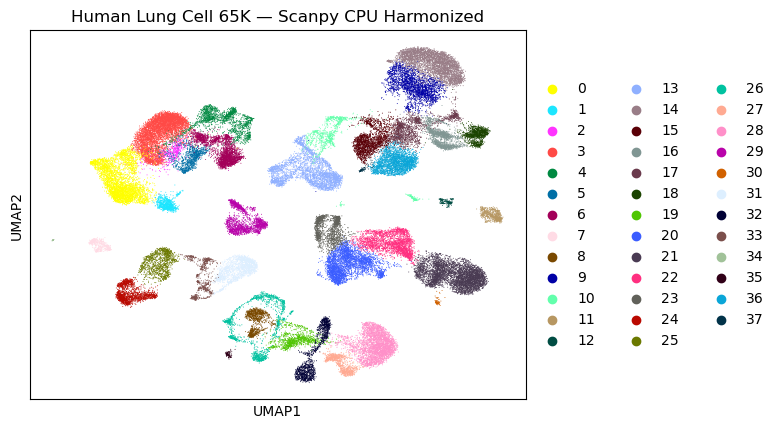

In [13]:
# Quick UMAP plot
sc.pl.umap(adata, color="leiden", title=f"{dcfg['name']} — Scanpy CPU Harmonized")